In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
from UTILS import Verlet_Update, step_all_particles, InitialCondition, dt, zacceptance_min, zacceptance_max
from UTILS import Gradient_Computation
from scipy.stats import maxwell
import time

In [2]:
!pip install numba

Defaulting to user installation because normal site-packages is not writeable


In [3]:
class constants:
    mass = 1.6735575e-27 # kg, mass Hbar
    bohr_magneton = 9.2740100657e-24 # J/T, CODATA 2022
    kB = 1.380649e-23   # J/K
    Temperature = 10e-3 # K
    Zmin = -0.605 # m
    Zmax = -0.481 # m
    Zmid = -0.544 # m
    zacceptance_min = -0.775
    zacceptance_max = -0.325
    mu_eff_over_m = .5 * bohr_magneton / mass

CONSTANTS = constants()

# Load Gravity Well

In [4]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_2p5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466533 -0.00465643 -0.0046475  ...  0.00595184  0.00595344
  0.00595506]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466541 -0.0046565  -0.00464758 ...  0.00595181  0.00595341
  0.00595504]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466567 -0.00465677 -0.00464784 ...  0.00595172  0.00595332
  0.00595495]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466573 -0.00465683 -0.0046479  ...  0.00595171  0.00595331
  0.00595493]


## Functions to make the plot nicer

In [5]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

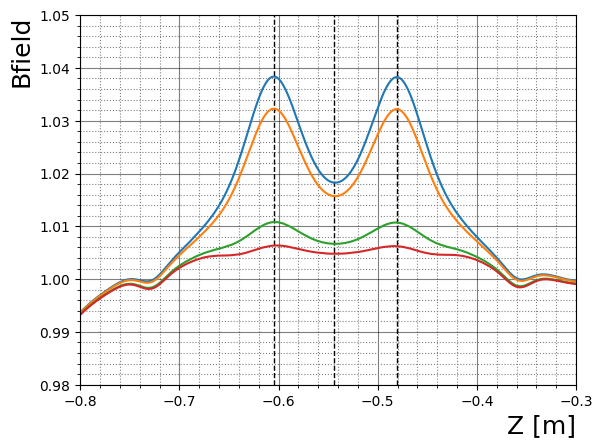

In [6]:
plotter_nicer("Z [m]", "Bfield")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)
plt.axvline(-0.605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

## Create the 3 segments

In [7]:
# Segment 1,
def segment1(Z,T, ramplength):
    return Bfield_20mT_pregravity(Z) + (Bfield_17mT(Z) - Bfield_20mT_pregravity(Z)) * ( T/ramplength)

# Segment 2,
def segment2(Z,T, ramplength):
    return Bfield_17mT(Z) + (Bfield_5mT(Z) - Bfield_17mT(Z)) * ( T/ramplength)

# Segment 3,
def segment3(Z,T, ramplength):
    return Bfield_5mT(Z) + (Bfield_2p5mT(Z) - Bfield_5mT(Z)) * ( T/ramplength)

## Create Gradient Grid

In [8]:
zgrid = np.linspace(-0.800, -0.300, 100000) # half mm of discretization
z0 = zgrid[0]
dz = np.diff(zgrid)[0]

dBfield_20mT_pregravity_dz = np.array(Gradient_Computation(Bfield_20mT_pregravity, zgrid))
dBfield_17mT_dz            = np.array(Gradient_Computation(Bfield_17mT, zgrid ))
dBfield_5mT_dz             = np.array(Gradient_Computation(Bfield_5mT, zgrid  ))
dBfield_2p5mT_dz           = np.array(Gradient_Computation(Bfield_2p5mT, zgrid))

In [9]:
#print(dBfield_20mT_pregravity_dz)

## Simulation Setting

In [10]:
nAtoms = 10000
Time = 0

Tramp1     = 10
wait_ramp1 = 10 + Tramp1

Tramp2     = 10 + wait_ramp1
wait_ramp2 = 10 + Tramp2

Tramp3     = 10 + wait_ramp2
wait_ramp3 = 10 + Tramp3

## Define variables for visualization

In [ ]:
import matplotlib.animation as animation
from matplotlib import rc
from matplotlib import rcParams
from IPython.display import HTML
plt.rcParams['figure.dpi']  = 120  # non 200-300
plt.rcParams['savefig.dpi'] = 120
rc('animation', html='jshtml')   # dice a Matplotlib di rendere l'animazione come HTML/JS

# Imposta il rendering e il limite di embed PRIMA di creare l'animazione
rcParams['animation.html'] = 'jshtml'
rcParams['animation.embed_limit'] = 800.0  # in MB (float)

fig, ax = plt.subplots()

ax.set_xlim(-0.800, -0.300)
ax.set_ylim(0.98, 1.05)
ax.set_xlabel("Z axis [m]", loc = "right")
ax.set_ylabel("Trap Field", loc = "top")

particles_plots = [ax.plot([], [], 'ro', markersize= 2)[0] for _ in range(nAtoms)]  # Palline rosse

# Testo per i contatori
left_count = 0
right_count = 0
asym = None

#text_left   = ax.text(-0.800 + 0.020,  1.04, f"Left: {left_count}", fontsize=7, color='blue')
#text_right  = ax.text(-0.300 - 0.050, 1.04, f"Right: {right_count}", fontsize=7, color='blue')

plt.plot(Z, Bfield_20mT_pregravity(Z))
plt.plot(Z, Bfield_17mT(Z))
plt.plot(Z, Bfield_5mT(Z))
plt.plot(Z, Bfield_2p5mT(Z))

## Simulation Test
- **Initialize the particles.**
- **loop to update the particles, verlet velocity.**
- **Define Up and down regions.**

In [ ]:
# # Initialize the atoms
# Time = 0
# left_count = 0
# right_count = 0

# # linea iniziale (metti un campo qualsiasi, verrà sovrascritto)
# y0 = Bfield_20mT_pregravity(zgrid)  # o quello che vuoi come "inizio"
# line, = ax.plot(zgrid, y0, lw=1.5, color = "black", linestyle = "--")

# def update(frame):
#     global Time, zgrid
#     left_count, right_count = 0, 0

#     if(frame % 100 == 0): print(f"frame {frame}")
#     # Avanza il tempo UNA volta per frame
#     Time += 0.1
#     #print(Time)

#     # ================================================================
#     # IDENTIFICAZIONE DEL SEGMENTO
#     # ================================================================
#     if (Time >= 0) and (Time < Tramp1):
#         # SEGMENTO 1
#         Bfield = lambda z: segment1(z, Time - 0, 10)
#     elif (Time >= Tramp1) and (Time < wait_ramp1):
#         # WAIT 1
#         Bfield = Bfield_17mT
#     elif (Time >= wait_ramp1) and (Time < Tramp2):
#         # SEGMENTO 2
#         Bfield = lambda z: segment2(z, Time - wait_ramp1, 10)
#     elif (Time >= Tramp2) and (Time < wait_ramp2):
#         # WAIT 2
#         Bfield = Bfield_5mT
#     elif (Time >= wait_ramp2) and (Time < Tramp3):
#         # SEGMENTO 3
#         Bfield = lambda z: segment3(z, Time - wait_ramp2, 10)
#     else:
#         # Fuori dai segmenti → lascia il campo finale
#         Bfield = Bfield_5mT


#     # ================================================================
#     # AGGIORNAMENTO DEL CAMPO
#     # ================================================================
#     line.set_data(zgrid, Bfield(zgrid))
    
#     # Ritornare SEMPRE tutti gli artist
#     return line

# ani = animation.FuncAnimation(
#     fig, update,
#     frames=500,
#     interval=16,
#     blit=False
# )


# HTML(ani.to_jshtml())            # <-- questo fa apparire l’animazione in JupyterLab

# SIMULATION

In [ ]:
# Initialize the atoms
Time = 0

# Initialize the particles
Z_array = []
V_array = []
Time_Annihilation = []
Annihilation = []
for _ in range(nAtoms):
    print("Extracting values:")
    Vinit, Zinit = InitialCondition(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
    Z_array.append(Zinit)             # Initial position
    V_array.append(Vinit)           # Initial speed
    Time_Annihilation.append(np.nan)  # Time annihilation
    Annihilation.append(False)        # Annihilation bool array

Z_array = np.array(Z_array).flatten()
V_array = np.array(V_array).flatten()
Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

In [ ]:
# dummy call
# mini chiamata “dummy” per triggerare la compilazione:
step_all_particles.py_func(
    Z_array, V_array, 0.0,
    0, 0.0, 10.0,
    z0, dz,
    dBfield_20mT_pregravity_dz, dBfield_17mT_dz,
    Annihilation, Time_Annihilation
)

In [ ]:
start_time = time.time()
for frame in range(0,int(wait_ramp3/dt)):
    if(frame % 1000 == 0):
        end = time.time() - start_time
        print(f"frame {frame}, time {end:.2f}s")
    #print(Time)

    # ================================================================
    # IDENTIFICAZIONE DEL SEGMENTO
    # ================================================================
        # identifica il segmento e i campi da passare
    if 0 <= Time < Tramp1:
        seg_id   = 0
        Tloc     = Time - 0.0
        ramp_len = 10.0
        dBinit   = dBfield_20mT_pregravity_dz
        dBfinal  = dBfield_17mT_dz

    elif Tramp1 <= Time < wait_ramp1:
        seg_id   = 1   # plateau
        Tloc     = 0.0
        ramp_len = 0.0
        dBinit   = dBfield_20mT_pregravity_dz  # non usato
        dBfinal  = dBfield_17mT_dz             # usi questo

    elif wait_ramp1 <= Time < Tramp2:
        seg_id   = 0
        Tloc     = Time - wait_ramp1
        ramp_len = 10.0
        dBinit   = dBfield_17mT_dz
        dBfinal  = dBfield_5mT_dz

    elif Tramp2 <= Time < wait_ramp2:
        seg_id   = 1
        Tloc     = 0.0
        ramp_len = 0.0
        dBinit   = dBfield_17mT_dz
        dBfinal  = dBfield_5mT_dz

    elif wait_ramp2 <= Time < Tramp3:
        seg_id   = 0
        Tloc     = Time - wait_ramp2
        ramp_len = 10.0
        dBinit   = dBfield_5mT_dz
        dBfinal  = dBfield_2p5mT_dz

    else:
        seg_id   = 1
        Tloc     = 0.0
        ramp_len = 0.0
        dBinit   = dBfield_5mT_dz
        dBfinal  = dBfield_2p5mT_dz

    # step di tutte le particelle (in-place)
    step_all_particles(
        Z_array, V_array, Time,
        seg_id, Tloc, ramp_len,
        z0, dz,
        dBinit, dBfinal,
        Annihilation, Time_Annihilation,
    )

    # Avanza il tempo UNA volta per frame
    Time += dt


In [ ]:
plt.figure(1, figsize = (10, 5))
plt.subplot(1,2,1)
plt.axvline(0, linestyle = '--', color = "black")
plt.axvline(Tramp1, linestyle = '--', color = "black")
plt.axvline(wait_ramp1, linestyle = '--', color = "black")
plt.axvline(Tramp2, linestyle = '--', color = "black")
plt.axvline(wait_ramp2, linestyle = '--', color = "black")
plt.axvline(Tramp3, linestyle = '--', color = "black")
plt.xlabel("Time s", loc = "right")
plt.hist(Time_Annihilation, color = "red", bins = 50, range = (0, 60), alpha = 0.5)
plt.subplot(1,2,2)
plt.hist(Z_array, bins = 50)
plt.axvline(CONSTANTS.zacceptance_min, linestyle = "--", color = 'black')
plt.axvline(CONSTANTS.zacceptance_max, linestyle = "--", color = 'black', label = "annihilation limits")
plt.xlabel("Z mm", loc = "right")
plt.legend(loc = "upper center")